# Outline
Node classification & edge prediction (Multitask learning)
Text encoder - all-MiniLM-L6-v2 from sentence-transformers

Architecture modification
Data Processing, GAT model, training loop

In [4]:
import sys
import torch

print(f"Python version: {sys.version}")
print(f"Path to interpreter: {sys.executable}")
print(f"Version of PyTorch: {torch.__version__}")
print(f"CUDA is available: {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    import os
    print("\Diagnosis:")
    if "cpu" in torch.__version__:
        print("-> GPU installation failed.")
    else:
        print("-> GPU installed but does not see card. Check nvidia driver.")

Python version: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
Path to interpreter: C:\Users\posko\anaconda3\envs\gat_latest\python.exe
Version of PyTorch: 2.5.1+cu118
CUDA is available: True


In [5]:
import numpy as np
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
import os
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt

C:\Users\posko\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


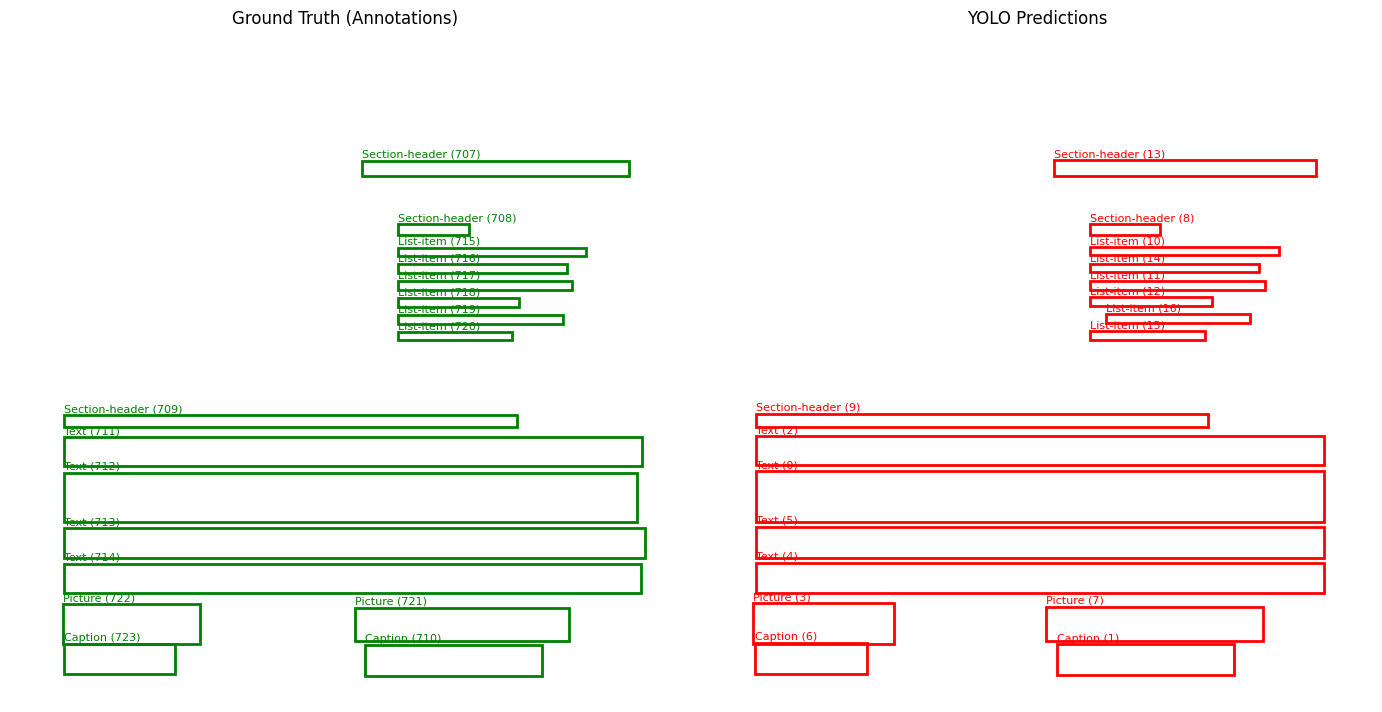

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json

def visualize_graph_side_by_side(graph):
    W, H = graph['width'], graph['height']

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # -----------------------------
    # LEFT: Ground Truth
    # -----------------------------
    ax = axes[0]
    ax.set_title("Ground Truth (Annotations)")
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)  # invert y-axis to match image coords

    for node in graph['nodes']:
        x, y, w, h = node['bbox']

        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2,
            edgecolor='green',
            facecolor='none'
        )
        ax.add_patch(rect)

        label = f"{node['category_name']} ({node['node_id']})"
        ax.text(x, y - 5, label, fontsize=8, color='green')

    # -----------------------------
    # RIGHT: YOLO Predictions
    # -----------------------------
    ax = axes[1]
    ax.set_title("YOLO Predictions")
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)

    for node in graph['yolo_nodes']:
        x1, y1, x2, y2 = node['geometry']['absolute_pixel_coords']
        w, h = x2 - x1, y2 - y1

        rect = patches.Rectangle(
            (x1, y1), w, h,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

        label = f"{node['label']} ({node['node_id']})"
        ax.text(x1, y1 - 5, label, fontsize=8, color='red')

    # -----------------------------
    # Formatting
    # -----------------------------
    for ax in axes:
        ax.set_aspect('equal')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

with open("data/DocLayNet/train_data/graph_000065.json", "r") as f:
    graph = json.load(f)

visualize_graph_side_by_side(graph)

# Build Node Features

In [7]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load once globally — never inside the function
miniLM = SentenceTransformer('all-MiniLM-L6-v2')
for param in miniLM.parameters():
    param.requires_grad = False

def iou(box_ann, box_yolo_abs):
    """
    box_ann       : [x, y, w, h]  — annotation format (origin + size)
    box_yolo_abs  : [x1, y1, x2, y2] — YOLO absolute pixel corners
    """
    ax1, ay1 = box_ann[0], box_ann[1]
    ax2, ay2 = ax1 + box_ann[2], ay1 + box_ann[3]

    bx1, by1, bx2, by2 = box_yolo_abs

    inter_w = max(0, min(ax2, bx2) - max(ax1, bx1))
    inter_h = max(0, min(ay2, by2) - max(ay1, by1))
    inter   = inter_w * inter_h
    union   = box_ann[2] * box_ann[3] \
              + (bx2 - bx1) * (by2 - by1) \
              - inter
    return inter / (union + 1e-6)


def build_node_features(graph, iou_threshold=0.5):
    image_W = graph['width']
    image_H = graph['height']
    ann_nodes  = graph['nodes']
    yolo_nodes = graph['yolo_nodes']

    # --- Step 1: compute all IoU pairs and sort by score descending ---
    pairs = []
    for yi, yn in enumerate(yolo_nodes):
        coords = yn['geometry']['absolute_pixel_coords']
        for ai, ann in enumerate(ann_nodes):
            score = iou(ann['bbox'], coords)
            if score >= iou_threshold:
                pairs.append((score, yi, ai))

    pairs.sort(reverse=True)  # greedy: best IoU pairs first

    # --- Step 2: greedy 1-to-1 assignment ---
    matched_yi  = set()   # yolo indices already claimed
    matched_ai  = set()   # annotated indices already claimed
    assignments = {}      # yolo_idx → ann_node

    for score, yi, ai in pairs:
        if yi in matched_yi or ai in matched_ai:
            continue
        assignments[yi] = ann_nodes[ai]
        matched_yi.add(yi)
        matched_ai.add(ai)

    # --- Step 3: build features only for matched yolo_nodes ---
    filtered_yolo    = []
    geom_features    = []
    texts            = []
    matched_node_ids = []

    for yi, yn in enumerate(yolo_nodes):
        ann = assignments.get(yi, None)

        if ann is None:
            # unmatched — skip for training, but you could log these
            continue

        coords = yn['geometry']['absolute_pixel_coords']
        x1, y1, x2, y2 = coords
        w, h = x2 - x1, y2 - y1
        area     = (w * h) / (image_W * image_H)
        x_center = (x1 + w / 2) / image_W
        y_center = (y1 + h / 2) / image_H
        w_norm   = w / image_W
        h_norm   = h / image_H
        aspect   = w / (h + 1e-6)

        cat_onehot = np.zeros(11)
        cat_onehot[ann['category_id'] - 1] = 1

        geom = np.array([x_center, y_center, w_norm, h_norm, area, aspect])
        geom_features.append(np.concatenate([geom, cat_onehot]))

        texts.append(yn.get('text', ''))
        filtered_yolo.append(yn)
        matched_node_ids.append(ann['node_id'])

    geom_features = np.array(geom_features)

    with torch.no_grad():
        text_embeddings = miniLM.encode(
            texts,
            convert_to_tensor=True,
            normalize_embeddings=True,
            show_progress_bar=False
        )

    return geom_features, text_embeddings, filtered_yolo, matched_node_ids

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 7593.44it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Edge index

In [8]:
def build_edge_index(edges, matched_node_ids):
    # matched_node_ids is now just a list of annotated node_ids — no .node_id lookup needed
    id_map = {ann_id: idx for idx, ann_id in enumerate(matched_node_ids)}

    edge_list, edge_labels = [], []
    for edge in edges:
        if edge['from'] in id_map and edge['to'] in id_map:
            edge_list.append([id_map[edge['from']], id_map[edge['to']]])
            edge_labels.append(edge['label'])

    if not edge_list:
        return torch.empty((2, 0), dtype=torch.long), torch.empty((0,), dtype=torch.float)

    return (torch.tensor(edge_list, dtype=torch.long).t().contiguous(),
            torch.tensor(edge_labels, dtype=torch.float))

# knn Graph construction

In [9]:
def build_knn_edges(features, k=3):
    """
    features: numpy array [num_nodes, feature_dim]
    prvé 2 dimenzie musia byť x_center, y_center
    """
    num_nodes = features.shape[0]

    if num_nodes <= 1:
        return torch.empty((2, 0), dtype=torch.long)

    actual_k = min(k, num_nodes - 1)

    centers = features[:, :2]  # x_center, y_center

    edge_list = []

    for i in range(num_nodes):

        dx = centers[:, 0] - centers[i, 0]
        dy = centers[:, 1] - centers[i, 1]
        
        # anisotropic distance (vertical more important)
        distances = np.sqrt(dx**2 + (1.5 * dy)**2)

        nearest = np.argsort(distances)[1:actual_k+1]  # jump yourself

        for j in nearest:
            edge_list.append([i, j])
            edge_list.append([j, i])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    return edge_index

# load data

In [10]:
CLASS_MAP = {
    1: 0,   # Caption -> 0
    7: 1,   # Picture -> 1
    9: 2,   # Table -> 2
    3: 3,   # Formula -> 3
    2: 4,   # Footnote
    4: 4,   # List-item
    5: 4,   # Page-footer
    6: 4,   # Page-header
    8: 4,   # Section-header
    10: 4,  # Text
    11: 4   # Title
}

def load_all_data(json_folder):
    all_graphs = []
    for filename in os.listdir(json_folder):
        if not filename.endswith(".json"):
            continue
        with open(os.path.join(json_folder, filename), encoding='utf-8') as f:
            graph = json.load(f)

        # BUG 1+2 fixed: use geom_features not features
        geom_features, text_emb, filtered_yolo, matched_node_ids = build_node_features(graph)
        x         = torch.tensor(geom_features, dtype=torch.float)
        knn_edges = build_knn_edges(geom_features, k=8)

        # BUG 3 fixed: pass matched_node_ids not filtered_nodes
        true_edge_index, true_edge_labels = build_edge_index(graph['edges'], matched_node_ids)

        # BUG 4 fixed: multi-class labels from matched annotations, not binary
        ann_id_to_cat = {n['node_id']: n['category_id'] for n in graph['nodes']}
        node_labels = torch.tensor(
            [CLASS_MAP[ann_id_to_cat[nid]] for nid in matched_node_ids], 
            dtype=torch.long
        )

        # BUG 5 fixed: store text_emb in Data
        data = Data(
            x                  = x,
            text_emb           = text_emb.cpu(),   # [N, 384] — projection happens in forward
            edge_index         = knn_edges,
            y_nodes            = node_labels,
            edge_index_targets = true_edge_index,
            y_edges            = true_edge_labels,
        )
        all_graphs.append(data)

    return all_graphs

# Data loader

In [11]:
SAVE_DIR = "data/DocLayNet/processed_data"
os.makedirs(SAVE_DIR, exist_ok=True)

train_path = os.path.join(SAVE_DIR, "train_graphs.pt")
val_path = os.path.join(SAVE_DIR, "val_graphs.pt")
test_path = os.path.join(SAVE_DIR, "test_graphs.pt")

if os.path.exists(train_path) and os.path.exists(val_path) and os.path.exists(test_path):
    print("Loading already preprocessed data from disk...")
    train_graphs = torch.load(train_path, weights_only=False)
    val_graphs = torch.load(val_path, weights_only=False)
    test_graphs = torch.load(test_path, weights_only=False)

else:
    print("Data not saved. Starting preprocessing...")
    train_graphs = load_all_data("data/DocLayNet/train_data")
    val_graphs = load_all_data("data/DocLayNet/val_data")
    test_graphs = load_all_data("data/DocLayNet/test_data")
    
    print("Saving processed data on the disk...")
    torch.save(train_graphs, train_path)
    torch.save(val_graphs, val_path)
    torch.save(test_graphs, test_path)

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_graphs, batch_size=32, shuffle=False)

print(f"Data are ready: Train({len(train_graphs)}), Val({len(val_graphs)}), Test({len(test_graphs)})")

Loading already preprocessed data from disk...
Data are ready: Train(23718), Val(6464), Test(4963)


# GAT Model

In [12]:
class GATMultitask(nn.Module):
    def __init__(self, geom_channels=17, text_channels=64,
                 hidden_channels=64, heads=4, num_node_classes=5):
        super().__init__()
        # text projection — only trainable text component
        self.proj = nn.Linear(text_channels, 64)

        in_channels = geom_channels + 64   # 17 + 64 = 81

        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels,
                             heads=1, concat=False)

        # node head: 11 classes (DocLayNet categories)
        self.node_head = nn.Linear(hidden_channels, num_node_classes)

        # edge head: same as before + distance feature
        # self.edge_head = nn.Sequential(
        #     nn.Linear(hidden_channels * 2 + 1, hidden_channels),
        #     nn.ReLU(),
        #     nn.Linear(hidden_channels, 1)
        # )
        # edge head: pridali sme abs_diff, takže zmeníme * 2 na * 3
        self.edge_head = nn.Sequential(
            nn.Linear(hidden_channels * 4 + 1, hidden_channels), # 🔥 Zmena tu
            nn.ReLU(),
            nn.Linear(hidden_channels, 1)
        )

    def forward(self, x_geom, text_emb, edge_index):
        text_proj = F.elu(self.proj(text_emb))              # [N, 64]
        x = torch.cat([x_geom, text_proj], dim=-1)          # [N, 81]

        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        z = self.conv2(x, edge_index)

        node_logits = self.node_head(z)                      # [N, 11]
        return z, node_logits

    # def predict_edges(self, z, edge_index, x_geom):
    #     pos_src = x_geom[edge_index[0], :2]
    #     pos_dst = x_geom[edge_index[1], :2]
    #     dist    = torch.norm(pos_src - pos_dst, dim=-1, keepdim=True)
    #     edge_features = torch.cat(
    #         [z[edge_index[0]], z[edge_index[1]], dist], dim=-1
    #     )
    #     return self.edge_head(edge_features).squeeze(-1)
    def predict_edges(self, z, edge_index, x_geom):
        src = edge_index[0]
        dst = edge_index[1]

        # 1. Výpočet vzdialenosti (Geometric distance)
        pos_src = x_geom[src, :2]
        pos_dst = x_geom[dst, :2]
        dist    = torch.norm(pos_src - pos_dst, dim=-1, keepdim=True)
        
        # 2. Vektory uzlov (Node embeddings)
        z_src = z[src]
        z_dst = z[dst]
        
        # 3. 🔥 Pridané interakčné členy (Interaction terms)
        abs_diff = torch.abs(z_src - z_dst)
        mult = z_src * z_dst  # ✅ Odkomentovaný Hadamardov súčin

        # 4. Spojenie všetkého dokopy (Concatenation)
        edge_features = torch.cat([
            z_src, 
            z_dst, 
            abs_diff,  
            mult,      # ✅ Tu ho musíš pridať do zoznamu
            dist
        ], dim=-1)
        
        return self.edge_head(edge_features).squeeze(-1)

# Node weight calculation
```
 ==================================================
    DATA ANALYSIS SUMMARY FOR data/DocLayNet/train_data
    ==================================================
    Total Files (Pages):     0
    Empty Pages (No Nodes):  0
    Pages with No Links:     11905
    Pages with Lone Caption: 0
    --------------------------------------------------
    Total Captions: 18492 | Total Connections: 18305
    --------------------------------------------------
    Formulas      | 7701       | 110
    Figures       | 21581      | 15493
    Tables        | 8711       | 2702
    Others        | 253440     | 0
    ==================================================
    

    ==================================================
    DATA ANALYSIS SUMMARY FOR data/DocLayNet/val_data
    ==================================================
    Total Files (Pages):     0
    Empty Pages (No Nodes):  0
    Pages with No Links:     5413
    Pages with Lone Caption: 0
    --------------------------------------------------
    Total Captions: 1740  | Total Connections: 1735
    --------------------------------------------------
    Formulas      | 1894       | 6
    Figures       | 2775       | 1450
    Tables        | 2269       | 279
    Others        | 90940      | 0
    ==================================================
    

    ==================================================
    DATA ANALYSIS SUMMARY FOR data/DocLayNet/test_data
    ==================================================
    Total Files (Pages):     0
    Empty Pages (No Nodes):  0
    Pages with No Links:     3967
    Pages with Lone Caption: 0
    --------------------------------------------------
    Total Captions: 1491  | Total Connections: 1479
    --------------------------------------------------
    Formulas      | 1966       | 3
    Figures       | 3534       | 1197
    Tables        | 2394       | 279
    Others        | 56735      | 0
    ==================================================
```

In [18]:
import numpy as np

counts = np.array([18492, 21581, 8711, 7701, 253440])
total  = counts.sum()          # 309,925
n_cls  = len(counts)           # 5

# ── Option A: inverse frequency ──────────────────────────────
inv_freq = total / (n_cls * counts)
inv_freq_norm = inv_freq / inv_freq.min()  # normalize so Other ≈ 1
# Caption: 13.9 | Picture: 11.9 | Table: 29.7 | Formula: 33.5 | Other: 1.0
# → very aggressive, can destabilize training early on

# ── Option B: sqrt inverse frequency (recommended) ───────────
sqrt_inv = np.sqrt(total / counts)
sqrt_inv_norm = sqrt_inv / sqrt_inv[-1]    # normalize so Other = 1.0
# Caption:  3.7 | Picture:  3.4 | Table:  5.4 | Formula:  5.8 | Other: 1.0
print(sqrt_inv_norm)
#node_weights = torch.tensor(sqrt_inv_norm, dtype=torch.float).to(device)

[3.70207862 3.42690289 5.39390848 5.73672482 1.        ]


In [13]:
import os
import torch
import torch.nn.functional as F
from collections import defaultdict
from sklearn.metrics import classification_report, confusion_matrix

# ── Paths ─────────────────────────────────────────────────────────────────────

RUN_NAME = "run_06_hadamar_multiplication" 
OUT_DIR  = os.path.join("models", "gat_graph_text", RUN_NAME)
os.makedirs(OUT_DIR, exist_ok=True)

# ── Init ──────────────────────────────────────────────────────────────────────

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("USING:", device)

model = GATMultitask(text_channels=384, num_node_classes=5).to(device)

node_weights = torch.tensor(
    [3.7, 3.4, 5.4, 5.8, 1.0],  # Caption, Picture, Table, Formula, Other
    dtype=torch.float
).to(device)

node_criterion = nn.CrossEntropyLoss(weight=node_weights)
edge_criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([2.5]).to(device)
)

optimizer = torch.optim.Adam(
    model.parameters(), lr=0.001, weight_decay=1e-4
)

# ── Train ─────────────────────────────────────────────────────────────────────

def train():
    model.train()
    total_loss = 0
    processed  = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        z, node_logits = model(
            batch.x,
            batch.text_emb.to(device),
            batch.edge_index
        )

        loss_node = node_criterion(node_logits, batch.y_nodes)

        loss_edge = torch.tensor(0.0, device=device)
        # if batch.edge_index_targets.numel() > 0:
        #     edge_preds = model.predict_edges(
        #         z, batch.edge_index_targets, batch.x
        #     )
        #     loss_edge = edge_criterion(edge_preds, batch.y_edges)

        if batch.edge_index_targets.numel() > 0:
            src = batch.edge_index_targets[0]
            dst = batch.edge_index_targets[1]
        
            src_cls = batch.y_nodes[src]
            dst_cls = batch.y_nodes[dst]
        
            # ❌ Identify Caption–Formula edges
            is_formula = ((src_cls == 0) & (dst_cls == 3)) | ((src_cls == 3) & (dst_cls == 0))
        
            # ✅ Keep everything except those
            valid_mask = ~is_formula

            if valid_mask.sum() > 0:
                edge_preds = model.predict_edges(
                    z,
                    batch.edge_index_targets[:, valid_mask],
                    batch.x
                )
                loss_edge = edge_criterion(
                    edge_preds,
                    batch.y_edges[valid_mask]
                )
        
                loss = loss_node + loss_edge
                loss.backward()
                optimizer.step()
        
                total_loss += loss.item()
                processed  += 1

    return total_loss / processed if processed > 0 else 0


def evaluate_loss(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            z, node_logits = model(
                batch.x, batch.text_emb.to(device), batch.edge_index
            )
            loss_node = node_criterion(node_logits, batch.y_nodes)
            loss_edge = torch.tensor(0.0, device=device)
            # if batch.edge_index_targets.numel() > 0:
            #     edge_preds = model.predict_edges(
            #         z, batch.edge_index_targets, batch.x
            #     )
            #     loss_edge = edge_criterion(edge_preds, batch.y_edges)
            if batch.edge_index_targets.numel() > 0:
                src = batch.edge_index_targets[0]
                dst = batch.edge_index_targets[1]
            
                src_cls = batch.y_nodes[src]
                dst_cls = batch.y_nodes[dst]
            
                is_formula = ((src_cls == 0) & (dst_cls == 3)) | ((src_cls == 3) & (dst_cls == 0))
                valid_mask = ~is_formula
            
                if valid_mask.sum() > 0:
                    edge_preds = model.predict_edges(
                        z,
                        batch.edge_index_targets[:, valid_mask],
                        batch.x
                    )
                    loss_edge = edge_criterion(
                        edge_preds,
                        batch.y_edges[valid_mask]
                    )
            total_loss += (loss_node + loss_edge).item()

    return total_loss / len(loader) if len(loader) > 0 else 0


# ── Training loop ─────────────────────────────────────────────────────────────

STOPPAGE      = 7
best_val_loss = float("inf")
worse_count   = 0
epoch         = 1
train_loss_history = []
val_loss_history   = []

print(f"\nSaving checkpoints to: {OUT_DIR}\n")

while worse_count < STOPPAGE:
    train_loss = train()
    val_loss   = evaluate_loss(val_loader)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    # filename carries both losses for easy inspection without loading
    checkpoint_path = os.path.join(
        OUT_DIR,
        f"epoch_{epoch:03d}_tl_{train_loss:.4f}_vl_{val_loss:.4f}.pt"
    )
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss':           train_loss,
        'val_loss':             val_loss,
    }, checkpoint_path)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        worse_count   = 0
        # also save a clean best-model file that gets overwritten each time
        torch.save(model.state_dict(), os.path.join(OUT_DIR, "best_model.pt"))
        print(f"Epoch {epoch:03d} | train: {train_loss:.4f} | val: {val_loss:.4f} | ✓ NEW BEST")
    else:
        worse_count += 1
        print(f"Epoch {epoch:03d} | train: {train_loss:.4f} | val: {val_loss:.4f} | worse ({worse_count}/{STOPPAGE})")

    epoch += 1

print(f"\nTraining done. Best val loss: {best_val_loss:.4f}")

def plot_losses(train_history, val_history, out_dir):
    plt.figure(figsize=(10, 6))
    
    # Plot the lines
    epochs = range(1, len(train_history) + 1)
    plt.plot(epochs, train_history, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, val_history, 'r-', label='Validation Loss', linewidth=2)
    
    # Find and mark the best validation epoch
    best_epoch = val_history.index(min(val_history)) + 1
    plt.axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5, label=f'Best Model (Epoch {best_epoch})')
    
    # Formatting
    plt.title('GAT Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Node CE + Edge BCE)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    
    # Save the plot to your RUN_NAME directory
    plot_path = os.path.join(out_dir, "loss_curve.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nSaved loss curve plot to: {plot_path}")
    
    # Optional: Display it if you are running in a Jupyter Notebook
    # plt.show()
    plt.close()

# Call the function using your recorded histories
plot_losses(train_loss_history, val_loss_history, OUT_DIR)


# ── Final evaluation ──────────────────────────────────────────────────────────

CAT_NAMES  = {0: "Caption", 1: "Picture", 2: "Table", 3: "Formula", 4: "Other"}
CAT_LABELS = [CAT_NAMES[i] for i in range(5)]

RELATION_NAMES = {
    frozenset([0, 1]): "Caption–Figure",
    frozenset([0, 2]): "Caption–Table"
}


def final_evaluation(loader):
    model.eval()

    all_node_preds,  all_node_labels = [], []
    all_edge_preds,  all_edge_labels = [], []
    relation_records = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            z, node_logits = model(
                batch.x, batch.text_emb.to(device), batch.edge_index
            )

            # node classification
            node_preds = node_logits.argmax(dim=-1)
            all_node_preds.extend(node_preds.cpu().numpy())
            all_node_labels.extend(batch.y_nodes.cpu().numpy())

            if batch.edge_index_targets.numel() == 0:
                continue

            # edge prediction
            edge_logits = model.predict_edges(
                z, batch.edge_index_targets, batch.x
            )
            edge_preds = (torch.sigmoid(edge_logits) > 0.5).float()

            # ── edge prediction ──────────────────────────────────────────
            # edge_logits = model.predict_edges(
            #     z, batch.edge_index_targets, batch.x
            # )
            # edge_scores = torch.sigmoid(edge_logits)
            
            # # 1. Get the predicted classes for the source and destination nodes of each edge
            # src_classes = node_preds[batch.edge_index_targets[0]]
            # dst_classes = node_preds[batch.edge_index_targets[1]]
            
            # # 2. Initialize a tensor of default thresholds (0.5)
            # thresholds = torch.full_like(edge_scores, 0.5)
            
            # # 3. Create boolean masks for specific relations (checking both directions)
            # # Caption (0) and Formula (3)
            # is_formula_link = ((src_classes == 0) & (dst_classes == 3)) | ((src_classes == 3) & (dst_classes == 0))
            
            # # Caption (0) and Figure (1)
            # is_figure_link = ((src_classes == 0) & (dst_classes == 1)) | ((src_classes == 1) & (dst_classes == 0))
            
            # # Caption (0) and Table (2)
            # is_table_link = ((src_classes == 0) & (dst_classes == 2)) | ((src_classes == 2) & (dst_classes == 0))
            
            # # 4. Apply your custom thresholds
            # thresholds[is_formula_link] = 0.85  # Be highly conservative with formulas
            # thresholds[is_figure_link]  = 0.60  # Slightly strict with figures to drop false positives
            # thresholds[is_table_link]   = 0.50  # Keep tables at default
            
            # # 5. Calculate final predictions using the dynamic thresholds
            # edge_preds = (edge_scores > thresholds).float()

            
            # all_edge_preds.extend(edge_preds.cpu().numpy())
            # all_edge_labels.extend(batch.y_edges.cpu().numpy())
            src = batch.edge_index_targets[0]
            dst = batch.edge_index_targets[1]
            
            src_cls = node_preds[src]
            dst_cls = node_preds[dst]
            
            is_formula = ((src_cls == 0) & (dst_cls == 3)) | ((src_cls == 3) & (dst_cls == 0))
            valid_mask = ~is_formula
            
            filtered_preds = edge_preds[valid_mask]
            filtered_labels = batch.y_edges[valid_mask]
            filtered_src = src[valid_mask]
            filtered_dst = dst[valid_mask]

            all_edge_preds.extend(filtered_preds.cpu().numpy())
            all_edge_labels.extend(filtered_labels.cpu().numpy())

            # per-relation breakdown
            node_cats = batch.y_nodes.cpu().numpy()
            src_nodes_np = filtered_src.cpu().numpy()
            dst_nodes_np = filtered_dst.cpu().numpy()

            for i, (s, d) in enumerate(zip(src_nodes_np, dst_nodes_np)):
                if s >= len(node_cats) or d >= len(node_cats):
                    continue
                pair = frozenset([int(node_cats[s]), int(node_cats[d])])
                relation_records.append({
                    "relation": RELATION_NAMES.get(pair, "Other"),
                    "pred":     int(filtered_preds[i].item()),
                    "label":    int(filtered_labels[i].item()),
                })

    print("\n══════════════════════════════════════════")
    print("  NODE CLASSIFICATION")
    print("══════════════════════════════════════════")
    print(classification_report(
        all_node_labels, all_node_preds,
        target_names=CAT_LABELS, zero_division=0
    ))
    print("Confusion matrix:")
    print(confusion_matrix(all_node_labels, all_node_preds))

    print("\n══════════════════════════════════════════")
    print("  EDGE PREDICTION (overall)")
    print("══════════════════════════════════════════")
    print(classification_report(
        all_edge_labels, all_edge_preds,
        target_names=["No link", "Linked"], zero_division=0
    ))
    print("Confusion matrix:")
    print(confusion_matrix(all_edge_labels, all_edge_preds))

    print("\n══════════════════════════════════════════")
    print("  EDGE PREDICTION — per relation type")
    print("══════════════════════════════════════════")
    buckets = defaultdict(lambda: {"preds": [], "labels": []})
    for r in relation_records:
        buckets[r["relation"]]["preds"].append(r["pred"])
        buckets[r["relation"]]["labels"].append(r["label"])

    for rel_name, data in sorted(buckets.items()):
        print(f"\n  {rel_name}  (n={len(data['labels'])})")
        print(classification_report(
            data["labels"], data["preds"],
            target_names=["No link", "Linked"], zero_division=0
        ))


# load best weights before evaluating
model.load_state_dict(torch.load(os.path.join(OUT_DIR, "best_model.pt"), weights_only=True))
final_evaluation(test_loader)

USING: cuda

Saving checkpoints to: models\gat_graph_text\run_06_hadamar_multiplication

Epoch 001 | train: 1.4815 | val: 0.5577 | ✓ NEW BEST
Epoch 002 | train: 0.9311 | val: 0.3233 | ✓ NEW BEST
Epoch 003 | train: 0.6129 | val: 0.2541 | ✓ NEW BEST
Epoch 004 | train: 0.5418 | val: 0.2258 | ✓ NEW BEST
Epoch 005 | train: 0.4583 | val: 0.2284 | worse (1/7)
Epoch 006 | train: 0.4341 | val: 0.2092 | ✓ NEW BEST
Epoch 007 | train: 0.4216 | val: 0.2019 | ✓ NEW BEST
Epoch 008 | train: 0.4064 | val: 0.2086 | worse (1/7)
Epoch 009 | train: 0.3848 | val: 0.2003 | ✓ NEW BEST
Epoch 010 | train: 0.3773 | val: 0.1892 | ✓ NEW BEST
Epoch 011 | train: 0.3688 | val: 0.1995 | worse (1/7)
Epoch 012 | train: 0.3672 | val: 0.1900 | worse (2/7)
Epoch 013 | train: 0.3599 | val: 0.2198 | worse (3/7)
Epoch 014 | train: 0.3516 | val: 0.2091 | worse (4/7)
Epoch 015 | train: 0.3456 | val: 0.1919 | worse (5/7)
Epoch 016 | train: 0.3390 | val: 0.1932 | worse (6/7)
Epoch 017 | train: 0.3293 | val: 0.2003 | worse (7/7)

